In [2]:
from lenskit.datasets import ML100K
from lenskit import batch, topn, util
from lenskit import crossfold as xf
from lenskit.algorithms import Recommender, als, item_knn as knn
from lenskit import topn
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
links = pd.read_csv("ml-32m/links.csv")
movies = pd.read_csv("ml-32m/movies.csv")
tags = pd.read_csv("ml-32m/tags.csv")
ratings = pd.read_csv("ml-32m/ratings.csv")

In [7]:
tags.isnull().sum()


userId        0
movieId       0
tag          17
timestamp     0
dtype: int64

In [8]:
tags[tags["tag"].isnull()]

,userId,movieId,tag,timestamp
185377,27046,33826,NaN,1221450908
1394089,89369,281500,NaN,1670942104
1914668,153443,123,NaN,1199450867
1914669,153443,346,NaN,1199451946
1914673,153443,1184,NaN,1199452261
1914680,153443,1785,NaN,1199452006
1914681,153443,2194,NaN,1199450677
1914683,153443,2691,NaN,1199451002
1914691,153443,4103,NaN,1199451920
1914693,153443,4473,NaN,1199451040


In [9]:
links.isnull().sum()


movieId      0
imdbId       0
tmdbId     124
dtype: int64

In [10]:
links[links["tmdbId"].isnull()]

,movieId,imdbId,tmdbId
706,721,114103,NaN
715,730,125877,NaN
754,770,38426,NaN
775,791,113610,NaN
1080,1107,102336,NaN
...,...,...,...
69664,224398,5868094,NaN
72372,234301,5714216,NaN
73033,237231,9372822,NaN
84374,281988,8031054,NaN


In [11]:
ratings

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858
...,...,...,...,...
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800


In [12]:
#show first instance of each table
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [13]:
#merge together movies and ratings
movies_ratings = pd.merge(movies, ratings, on="movieId")

<BarContainer object of 10 artists>

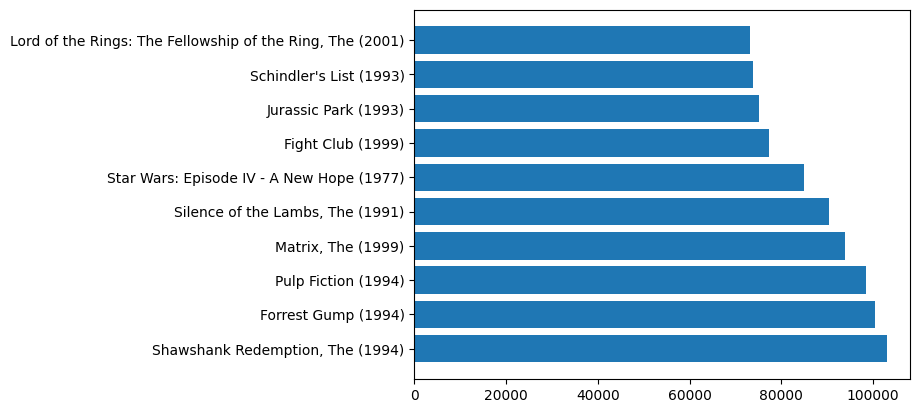

In [33]:
#see which movies have the most ratings by joining the movies and ratings tables
plt.barh(movies_ratings.groupby("title")["rating"].count().sort_values(ascending=False).head(10).index, movies_ratings.groupby("title")["rating"].count().sort_values(ascending=False).head(10).values)


In [23]:
#show which movies of over 10,000 ratings have the highest average rating
movies_ratings.groupby("title").filter(lambda x: len(x) > 10000).groupby("title")["rating"].mean().sort_values(ascending=False).head(10)

#create a new column in the dataset to account for average movie rating
movies_ratings["avg_rating"] = movies_ratings.groupby("title")["rating"].transform(lambda x: x.mean())


In [16]:
#create column for amount of reviews
movies_ratings["review_count"] = movies_ratings.groupby("title")["rating"].transform(lambda x: x.count())

In [28]:
#using review_count and avg_rating, visualize the top 10 movies with over 10,000 reviews using matplotlib
# plt.barh(movies_ratings["avg_rating"].sort_values(ascending=False).head(10).index, movies_ratings["avg_rating"].sort_values(ascending=False).head(10).values)
filtered_review_movies = movies_ratings[movies_ratings["review_count"] > 10000]
#remove duplicate movies from top 10 movies with the movieid key
top_10_movies = filtered_review_movies.groupby("title").filter(lambda x: len(x) > 1000).groupby("title")["avg_rating"].mean().sort_values(ascending=False).head(10)

In [31]:

top_10_movies
plt.barh(top_10_movies.index, top_10_movies.values) # . index is movie names, .values is the average rating
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.title('Top 10 Movies by Average Rating (with at least 10000 reviews)')
plt.show()

Index(['Shawshank Redemption, The (1994)', 'Godfather, The (1972)',
       'Parasite (2019)', '12 Angry Men (1957)', 'Usual Suspects, The (1995)',
       'Godfather: Part II, The (1974)',
       'Seven Samurai (Shichinin no samurai) (1954)',
       'Schindler's List (1993)', 'Fight Club (1999)', 'Rear Window (1954)'],
      dtype='object', name='title')

In [22]:
#create dataset of only comedy movies
comedy_movies = movies_ratings[movies_ratings["genres"].str.contains("Comedy")]

#find the top 5 highest rated comedies with at least 10k reviews
comedy_movies = comedy_movies[comedy_movies["review_count"] > 10000]

#sort by average rating and then plot the top 10
comedy_movies = comedy_movies.groupby("title")["avg_rating"].mean().sort_values(ascending=False).head(10)


In [20]:

comedy_movies

title
Parasite (2019)                                                                4.312254
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)    4.202680
Pulp Fiction (1994)                                                            4.196969
Life Is Beautiful (La Vita è bella) (1997)                                     4.150374
Sting, The (1973)                                                              4.143218
Monty Python and the Holy Grail (1975)                                         4.135633
Princess Bride, The (1987)                                                     4.119109
Intouchables (2011)                                                            4.118810
Fargo (1996)                                                                   4.116533
Wallace & Gromit: The Wrong Trousers (1993)                                    4.111800
Name: avg_rating, dtype: float64